In [9]:
import json
from collections import Counter
from pathlib import Path

train_path = Path("../data/simulated_s1_gap_between/train.jsonl")
valid_path = Path("../data/simulated_s1_gap_between/valid.jsonl")
cfg_path = Path("../data/simulated_s1_gap_between/config.json")


def load_jsonl(path, max_n=None):
    out = []
    with open(path) as f:
        for i, line in enumerate(f):
            out.append(json.loads(line))
            if max_n and (i+1) >= max_n:
                break
    return out


train = load_jsonl(train_path)
valid = load_jsonl(valid_path)

print("train:", len(train), "valid:", len(valid))
print("train case counts:", Counter(r["case"] for r in train))
print("valid case counts:", Counter(r["case"] for r in valid))

cfg = json.loads(cfg_path.read_text())
print("config:", cfg)


train: 20000 valid: 2000
train case counts: Counter({'both_valid': 9893, 'B_only': 5108, 'A_only': 4999})
valid case counts: Counter({'both_valid': 1009, 'A_only': 498, 'B_only': 493})
config: {'length': 200, 'motif_a': 'ATATTCA', 'motif_b': 'GTACTGC', 'spacing_multiple': 10, 'k_range': [1, 8], 'p_both_valid': 0.5, 'p_a_only': 0.25, 'p_b_only': 0.25, 'gap_rate_between': 0.15, 'gap_min': 0, 'gap_max': 999999, 'seed': 1}


In [10]:
def check_gaps_only_between(records, motif_a_len):
    bad = 0
    total = 0
    for r in records:
        if r["case"] != "both_valid":
            continue
        seq = r["sequence"]
        a = r["a_start"]
        b = r["b_start"]
        a_end = a + motif_a_len
        outside = seq[:a_end] + seq[b:]
        if "-" in outside:
            bad += 1
        total += 1
    return total, bad
    

motif_a_len = len(cfg["motif_a"])
total, bad = check_gaps_only_between(train, motif_a_len)
print("both_valid checked:", total, "outside-gap bad:", bad)
assert bad == 0, "Found gaps outside the between-motifs region!"


both_valid checked: 9893 outside-gap bad: 0


gap_count mean/min/max: 6.720004043262914 0 23
unique spacings: [np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80)]  ... (n_unique: 8 )


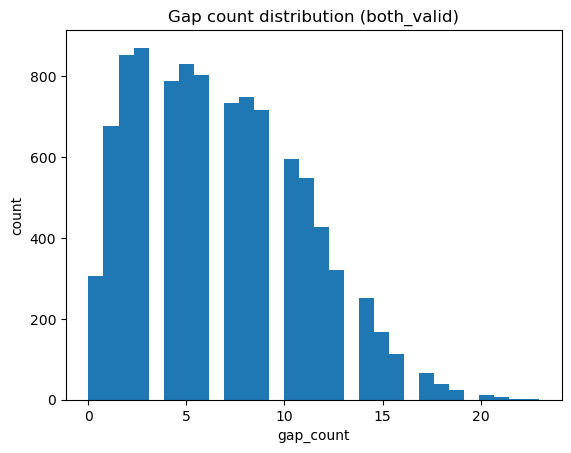

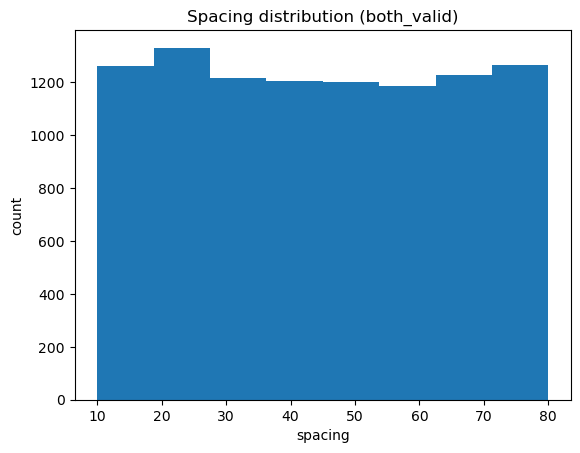

In [11]:
import numpy as np
import matplotlib.pyplot as plt

gap_counts = np.array([r["gap_count"] for r in train if r["case"] == "both_valid"])
spacings = np.array([r["spacing"] for r in train if r["case"] == "both_valid"])

print("gap_count mean/min/max:", gap_counts.mean(), gap_counts.min(), gap_counts.max())
print("unique spacings:", sorted(set(spacings))[:20], " ... (n_unique:", len(set(spacings)), ")")
assert np.all(spacings % cfg["spacing_multiple"] == 0)

plt.figure()
plt.hist(gap_counts, bins=30)
plt.title("Gap count distribution (both_valid)")
plt.xlabel("gap_count"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(spacings, bins=len(set(spacings)))
plt.title("Spacing distribution (both_valid)")
plt.xlabel("spacing"); plt.ylabel("count")
plt.show()


In [12]:
import random

def pretty_view(r, motif_a, motif_b):
    seq = r["sequence"]
    a = r["a_start"]; b = r["b_start"]
    la = len(motif_a); lb = len(motif_b)

    mark = [" "] * len(seq)
    if a >= 0:
        for i in range(a, a+la): mark[i] = "A"
    if b >= 0:
        for i in range(b, b+lb): mark[i] = "B"
    if r["gap_region"] is not None:
        gs, ge = r["gap_region"]
        for i in range(gs, ge):
            if mark[i] == " ": mark[i] = "."
    return seq, "".join(mark)

motif_a = cfg["motif_a"]; motif_b = cfg["motif_b"]
both = [r for r in train if r["case"] == "both_valid"]
r = random.choice(both)

seq_line, mark_line = pretty_view(r, motif_a, motif_b)
print("case:", r["case"], "a_start:", r["a_start"], "b_start:", r["b_start"], "spacing:", r["spacing"], "gap_count:", r["gap_count"])
print(seq_line)
print(mark_line)
print("Legend: A/B=motifs, .=between region")


case: both_valid a_start: 129 b_start: 156 spacing: 20 gap_count: 0
GCTTCACATTATACTCGAGGCCTGACGGTTAGCCCTAGCACAGATAGTTAATGCCGGTTAGATATATTCGTGCCGACACTTACATGAATTGGGGCCGTAATGATGTAGTTGCGCTTTTAAGTGCGCCAGATATTCACTCTTTTAACATACGAATAAGTACTGCGAGTGACGTTCCCCTTCCTGGTACATCCGAACCTTCC
                                                                                                                                 AAAAAAA....................BBBBBBB                                     
Legend: A/B=motifs, .=between region
